In [2]:
import numpy as np
import pandas as pd
from config import SimConfig
from src.data_processing import (
    load_and_cache_entire_fleet, 
    fit_dtmc, 
    downsample_block_mean
)
from src.plants.fc_only_plant import FuelCellOnlyPlant
from src.solvers.sdp_baseline import BaselineSDPSolver
from src.controllers.threshold import ThresholdControl
from src.controllers.stochastic import StochasticControl
from src.simulator import Simulator

# Instantiate your global configuration profile
config = SimConfig()
print(f"Configuration loaded. Macro time-step (Ts) set to: {config.Ts} seconds.")

Configuration loaded. Macro time-step (Ts) set to: 300 seconds.


In [ ]:
# Securely load all 14 operational profiles into memory to lock disk I/O
fleet_data = load_and_cache_entire_fleet(config)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [3]:
def run_validation_experiment(train_day_indices: list[int], test_day_idx: int) -> dict:
    """
    Calibrates the stochastic model on training days, executes the offline solver, 
    and simulates the performance metrics on an unseen test day profile.
    """
    # 1. FIX: Downsample each training day INDEPENDENTLY to preserve time topology
    train_segments = []
    for day in train_day_indices:
        raw_train = fleet_data[day]
        ds_train = downsample_block_mean(raw_train['t'], raw_train['Pd'], config.Ts, align='t0')
        train_segments.append(ds_train['Pd'])
        
    # 2. FIX: Feed the list of isolated segments directly into the segment-aware MC fitter
    mc_model = fit_dtmc(train_segments, config.n_states, config.alpha)
    
    # 3. Extract and downsample the unseen test profile trajectory
    test_raw = fleet_data[test_day_idx]
    ds_test = downsample_block_mean(test_raw['t'], test_raw['Pd'], config.Ts, align='t0')
    test_Pd = ds_test['Pd']
    
    # 4. Instantiate the Physical Asset (The Plant Env)
    plant = FuelCellOnlyPlant(config)
    
    # 5. Trigger the Offline Bellman Induction Solver
    sdp_solver = BaselineSDPSolver(config, mc_model)
    policy_matrix = sdp_solver.compute_policy_matrix(horizon_length=len(test_Pd))
    
    # 6. Instantiate Online Controllers (Injecting the precomputed matrix)
    sdp_ctrl = StochasticControl(
        states=mc_model['levels'], 
        n_vals=config.n_vals, 
        policy_matrix=policy_matrix
    )
    thres_ctrl = ThresholdControl(config)
    
    # 7. Execute Simulations
    sim_sdp = Simulator(config, test_Pd, plant)
    sdp_cost = sim_sdp.run(sdp_ctrl)
    
    sim_thres = Simulator(config, test_Pd, plant)
    thres_cost = sim_thres.run(thres_ctrl)
    
    return {
        'sdp_cost': sdp_cost,
        'heuristic_cost': thres_cost,
        'delta_advantage': thres_cost - sdp_cost
    }

In [4]:
results_a = []
# Our new baseline strictly ignores Days 1, 2, and 3
valid_days = range(4, 15)

print("Starting Approach A: Leave-One-Day-Out Cross-Validation (Cleaned Baseline)...")
for test_day in valid_days:
    # Train on every valid operational dataset EXCEPT the current testing dataset
    train_days = [d for d in valid_days if d != test_day]
    
    metrics = run_validation_experiment(train_days, test_day)
    results_a.append({
        'Test Target': f"Day {test_day:02d}",
        'SDP Cost': metrics['sdp_cost'],
        'Heuristic Cost': metrics['heuristic_cost'],
        'Delta Advantage (Thres - SDP)': metrics['delta_advantage']
    })

df_a = pd.DataFrame(results_a)
df_a.set_index('Test Target', inplace=True)
display(df_a.style.format("{:.2f}"))

Starting Approach A: Leave-One-Day-Out Cross-Validation (Cleaned Baseline)...


,SDP Cost,Heuristic Cost,Delta Advantage (Thres - SDP)
Test Target,,,
Day 04,134.62,118.02,-16.60
Day 05,40.13,38.94,-1.18
Day 06,123.05,108.84,-14.21
Day 07,130.07,105.95,-24.11
Day 08,92.72,95.27,2.55
Day 09,112.19,97.08,-15.10
Day 10,82.58,76.02,-6.56
Day 11,117.05,95.69,-21.36
Day 12,138.95,105.61,-33.34


In [6]:
results_b = []
print("Starting Approach B: Chronological Forward Chaining (Anchored at Day 04)...")

# Start testing on Day 07 to guarantee a minimum 3-day training history (Days 4, 5, 6)
for test_day in range(7, 15):
    # Dynamically expand the training window from Day 4 up to the day before the test
    train_days = list(range(4, test_day))
    training_horizon_length = len(train_days)
    
    metrics = run_validation_experiment(train_days, test_day)
    results_b.append({
        'Training Horizon History': f"{training_horizon_length} Day(s)",
        'Unseen Test Target': f"Day {test_day:02d}",
        'SDP Cost': metrics['sdp_cost'],
        'Heuristic Cost': metrics['heuristic_cost'],
        'Delta Advantage (Thres - SDP)': metrics['delta_advantage']
    })

df_b = pd.DataFrame(results_b)
df_b.set_index('Training Horizon History', inplace=True)
# Formatting to match the previous summary tables
display(df_b.style.format(subset=['SDP Cost', 'Heuristic Cost', 'Delta Advantage (Thres - SDP)'], formatter="{:.2f}"))

Starting Approach B: Chronological Forward Chaining (Anchored at Day 04)...


,Unseen Test Target,SDP Cost,Heuristic Cost,Delta Advantage (Thres - SDP)
Training Horizon History,,,,
3 Day(s),Day 07,128.28,105.95,-22.32
4 Day(s),Day 08,87.79,95.27,7.48
5 Day(s),Day 09,110.62,97.08,-13.54
6 Day(s),Day 10,83.40,76.02,-7.37
7 Day(s),Day 11,116.77,95.69,-21.08
8 Day(s),Day 12,140.09,105.61,-34.48
9 Day(s),Day 13,150.29,130.36,-19.94
10 Day(s),Day 14,118.25,104.66,-13.59


### GLOBAL SUMMARY STATISTICS
* Fleet-Wide SDP Average Simulation Cost:            113.48
* Fleet-Wide Heuristic Average Simulation Cost:      99.32
* Global Structural Generalization Advantage (Mean): -14.16



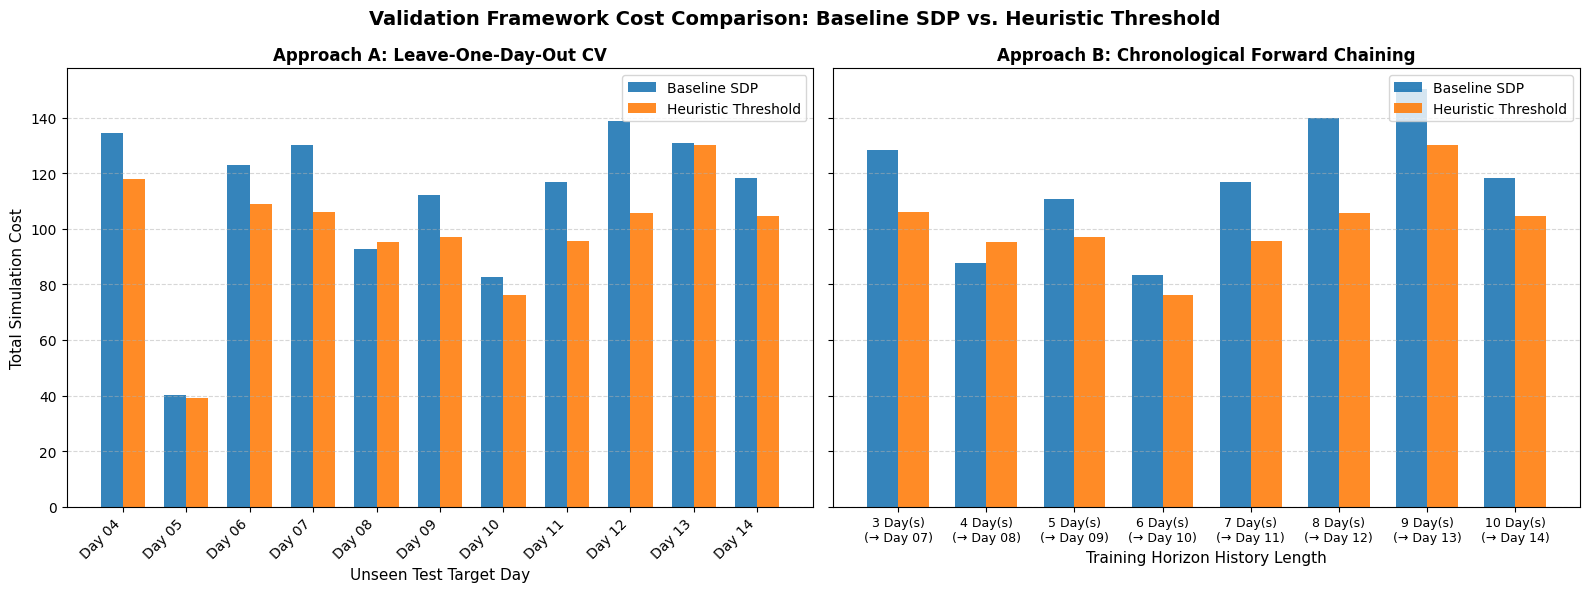

In [7]:
import matplotlib.pyplot as plt

# 1. Compute and print the text-based summary statistics
total_sdp_costs = list(df_a['SDP Cost']) + list(df_b['SDP Cost'])
total_heuristic_costs = list(df_a['Heuristic Cost']) + list(df_b['Heuristic Cost'])

print("=" * 70)
print("### GLOBAL SUMMARY STATISTICS")
print("=" * 70)
print(f"* Fleet-Wide SDP Average Simulation Cost:            {np.mean(total_sdp_costs):.2f}")
print(f"* Fleet-Wide Heuristic Average Simulation Cost:      {np.mean(total_heuristic_costs):.2f}")
print(f"* Global Structural Generalization Advantage (Mean): {np.mean(total_heuristic_costs) - np.mean(total_sdp_costs):.2f}")
print("=" * 70 + "\n")

# 2. Set up a professional dual-subplot figure for the notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Validation Framework Cost Comparison: Baseline SDP vs. Heuristic Threshold", fontsize=14, fontweight='bold')

# --- Left Subplot: Approach A (Leave-One-Day-Out) ---
x_a = np.arange(len(df_a.index))
width = 0.35

ax1.bar(x_a - width/2, df_a['SDP Cost'], width, label='Baseline SDP', color='#1f77b4', alpha=0.9)
ax1.bar(x_a + width/2, df_a['Heuristic Cost'], width, label='Heuristic Threshold', color='#ff7f0e', alpha=0.9)

ax1.set_title("Approach A: Leave-One-Day-Out CV", fontsize=12, fontweight='semibold')
ax1.set_xlabel("Unseen Test Target Day", fontsize=11)
ax1.set_ylabel("Total Simulation Cost", fontsize=11)
ax1.set_xticks(x_a)
ax1.set_xticklabels(df_a.index, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# --- Right Subplot: Approach B (Chronological Forward Chaining) ---
x_b = np.arange(len(df_b.index))

ax2.bar(x_b - width/2, df_b['SDP Cost'], width, label='Baseline SDP', color='#1f77b4', alpha=0.9)
ax2.bar(x_b + width/2, df_b['Heuristic Cost'], width, label='Heuristic Threshold', color='#ff7f0e', alpha=0.9)

ax2.set_title("Approach B: Chronological Forward Chaining", fontsize=12, fontweight='semibold')
ax2.set_xlabel("Training Horizon History Length", fontsize=11)
# Create a cleaner x-tick layout by combining the training size and the target day
x_labels_b = [f"{hist}\n(→ {target})" for hist, target in zip(df_b.index, df_b['Unseen Test Target'])]
ax2.set_xticks(x_b)
ax2.set_xticklabels(x_labels_b, rotation=0, fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()